# **Introduction**

---


Sepsis is a life-threatening medical emergency where your body overreacts to an infection, causing your immune system to damage your own organs and tissues instead of just fighting the germs. Sepsis is a critical concern in healthcare, and early diagnosis can significantly improve patient outcomes. In this project we will try to a machine learning model for sepsis prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("Paitients_Files_Train.csv")
train_df.head()

,ID,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance,Sepssis
0,ICU200010,6,148,72,35,0,33.6,0.627,50,0,Positive
1,ICU200011,1,85,66,29,0,26.6,0.351,31,0,Negative
2,ICU200012,8,183,64,0,0,23.3,0.672,32,1,Positive
3,ICU200013,1,89,66,23,94,28.1,0.167,21,1,Negative
4,ICU200014,0,137,40,35,168,43.1,2.288,33,1,Positive


In [3]:
test_df = pd.read_csv("Paitients_Files_Test.csv")
test_df.head()

,ID,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance
0,ICU200609,1,109,38,18,120,23.1,0.407,26,1
1,ICU200610,1,108,88,19,0,27.1,0.400,24,1
2,ICU200611,6,96,0,0,0,23.7,0.190,28,1
3,ICU200612,1,124,74,36,0,27.8,0.100,30,1
4,ICU200613,7,150,78,29,126,35.2,0.692,54,0


# **Columns Description-**
1. ID: A unique identifier for each patient.
2. PRG: Number of pregnancies (applicable only to females).
3. PL: Plasma glucose concentration.
4. PR: Diastolic blood pressure.
5. SK: Triceps skinfold thickness.
6. TS: 2-hour serum insulin.
7. M11: Body mass index (BMI).
8. BD2: Diabetes pedigree function.
9. Age: Age of the patient.
10. Insurance: Whether the patient has insurance coverage (1 for Yes, 0 for No).
11. Sepsis: The presence or absence of sepsis (Positive for presence, Negative for absence).




In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         599 non-null    object 
 1   PRG        599 non-null    int64  
 2   PL         599 non-null    int64  
 3   PR         599 non-null    int64  
 4   SK         599 non-null    int64  
 5   TS         599 non-null    int64  
 6   M11        599 non-null    float64
 7   BD2        599 non-null    float64
 8   Age        599 non-null    int64  
 9   Insurance  599 non-null    int64  
 10  Sepssis    599 non-null    object 
dtypes: float64(2), int64(7), object(2)
memory usage: 51.6+ KB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         169 non-null    object 
 1   PRG        169 non-null    int64  
 2   PL         169 non-null    int64  
 3   PR         169 non-null    int64  
 4   SK         169 non-null    int64  
 5   TS         169 non-null    int64  
 6   M11        169 non-null    float64
 7   BD2        169 non-null    float64
 8   Age        169 non-null    int64  
 9   Insurance  169 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 13.3+ KB


In [6]:
print(train_df.shape)
print(test_df.shape)

(599, 11)
(169, 10)


In [7]:
train_df.describe()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance
count,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000
mean,3.824708,120.153589,68.732888,20.562604,79.460768,31.920033,0.481187,33.290484,0.686144
std,3.362839,32.682364,19.335675,16.017622,116.576176,8.008227,0.337552,11.828446,0.464447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.100000,0.248000,24.000000,0.000000
50%,3.000000,116.000000,70.000000,23.000000,36.000000,32.000000,0.383000,29.000000,1.000000
75%,6.000000,140.000000,80.000000,32.000000,123.500000,36.550000,0.647000,40.000000,1.000000
max,17.000000,198.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
test_df.describe()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance
count,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,3.917160,123.520710,70.426036,20.443787,81.000000,32.249704,0.438876,33.065089,0.727811
std,3.402415,29.259123,19.426805,15.764962,110.720852,7.444886,0.306935,11.548110,0.446410
min,0.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.100000,21.000000,0.000000
25%,1.000000,102.000000,62.000000,0.000000,0.000000,27.600000,0.223000,24.000000,0.000000
50%,3.000000,120.000000,74.000000,23.000000,0.000000,32.400000,0.343000,28.000000,1.000000
75%,6.000000,141.000000,80.000000,32.000000,135.000000,36.600000,0.587000,42.000000,1.000000
max,13.000000,199.000000,114.000000,49.000000,540.000000,57.300000,1.698000,70.000000,1.000000


In [9]:
datasets = {'train': train_df, 'test': test_df}
def show_missing_values(datasets):
    for name, data in datasets.items():
        print(f"Missing values in the {name} dataset:")
        print(data.isnull().sum())
        print(f"Duplicate values in the {name} dataset:")
        print(data.duplicated().sum())
        print('---' * 18)
        print()
show_missing_values(datasets)

Missing values in the train dataset:
ID           0
PRG          0
PL           0
PR           0
SK           0
TS           0
M11          0
BD2          0
Age          0
Insurance    0
Sepssis      0
dtype: int64
Duplicate values in the train dataset:
0
------------------------------------------------------

Missing values in the test dataset:
ID           0
PRG          0
PL           0
PR           0
SK           0
TS           0
M11          0
BD2          0
Age          0
Insurance    0
dtype: int64
Duplicate values in the test dataset:
0
------------------------------------------------------



Individual analysis of each variable

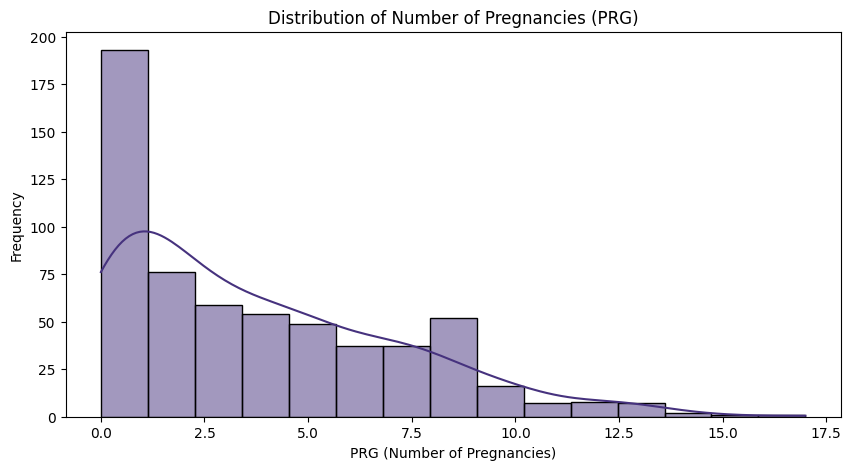

Summary Statistics for Number of Pregnancies (PRG):
count    599.000000
mean       3.824708
std        3.362839
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: PRG, dtype: float64


In [10]:
prg_values = train_df['PRG']
plt.figure(figsize=(10, 5))
sns.histplot(prg_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Number of Pregnancies (PRG)')
plt.xlabel('PRG (Number of Pregnancies)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Number of Pregnancies (PRG):')
print(prg_values.describe())

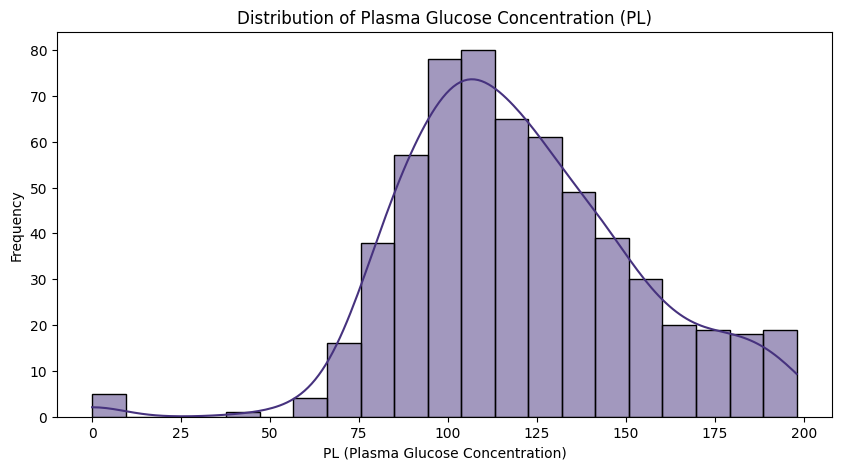

Summary Statistics for Plasma Glucose Concentration (PL):
count    599.000000
mean     120.153589
std       32.682364
min        0.000000
25%       99.000000
50%      116.000000
75%      140.000000
max      198.000000
Name: PL, dtype: float64


In [11]:
pl_values = train_df['PL']
plt.figure(figsize=(10, 5))
sns.histplot(pl_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Plasma Glucose Concentration (PL)')
plt.xlabel('PL (Plasma Glucose Concentration)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Plasma Glucose Concentration (PL):')
print(pl_values.describe())

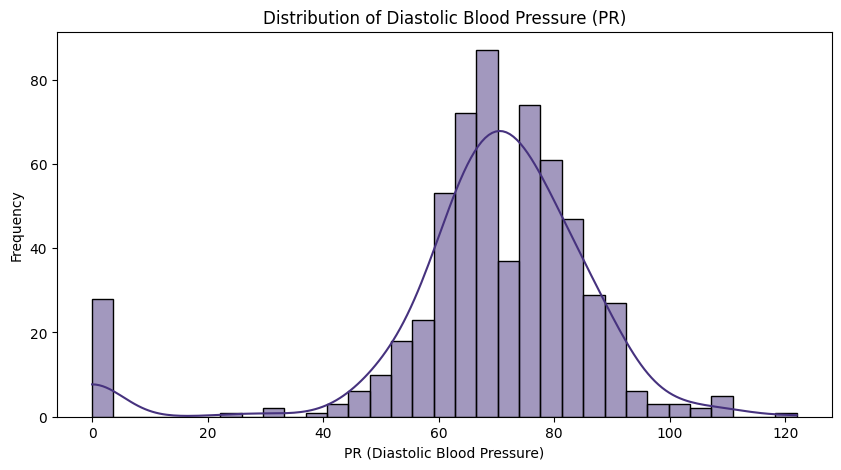

Summary Statistics for Diastolic Blood Pressure (PR):
count    599.000000
mean      68.732888
std       19.335675
min        0.000000
25%       64.000000
50%       70.000000
75%       80.000000
max      122.000000
Name: PR, dtype: float64


In [12]:
pr_values = train_df['PR']
plt.figure(figsize=(10, 5))
sns.histplot(pr_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Diastolic Blood Pressure (PR)')
plt.xlabel('PR (Diastolic Blood Pressure)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Diastolic Blood Pressure (PR):')
print(pr_values.describe())

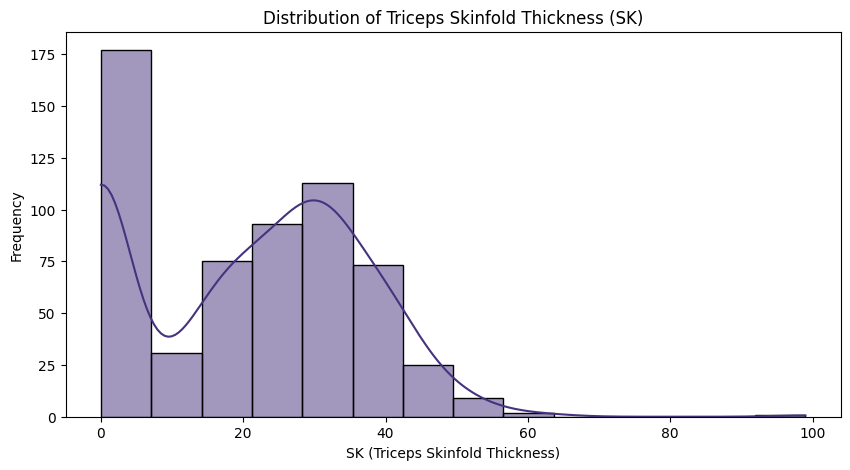

Summary Statistics for Triceps Skinfold Thickness (SK):
count    599.000000
mean      20.562604
std       16.017622
min        0.000000
25%        0.000000
50%       23.000000
75%       32.000000
max       99.000000
Name: SK, dtype: float64


In [13]:
sk_values = train_df['SK']
plt.figure(figsize=(10, 5))
sns.histplot(sk_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Triceps Skinfold Thickness (SK)')
plt.xlabel('SK (Triceps Skinfold Thickness)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Triceps Skinfold Thickness (SK):')
print(sk_values.describe())

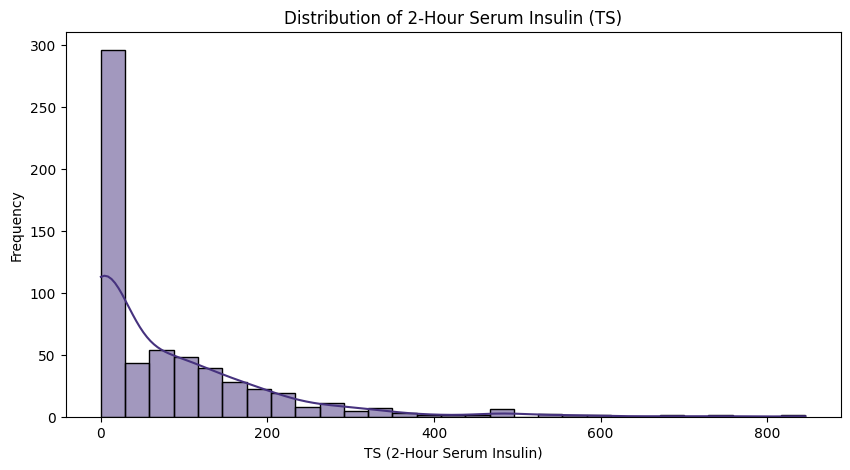

Summary Statistics for 2-Hour Serum Insulin (TS):
count    599.000000
mean      79.460768
std      116.576176
min        0.000000
25%        0.000000
50%       36.000000
75%      123.500000
max      846.000000
Name: TS, dtype: float64


In [14]:
ts_values = train_df['TS']
plt.figure(figsize=(10, 5))
sns.histplot(ts_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of 2-Hour Serum Insulin (TS)')
plt.xlabel('TS (2-Hour Serum Insulin)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for 2-Hour Serum Insulin (TS):')
print(ts_values.describe())

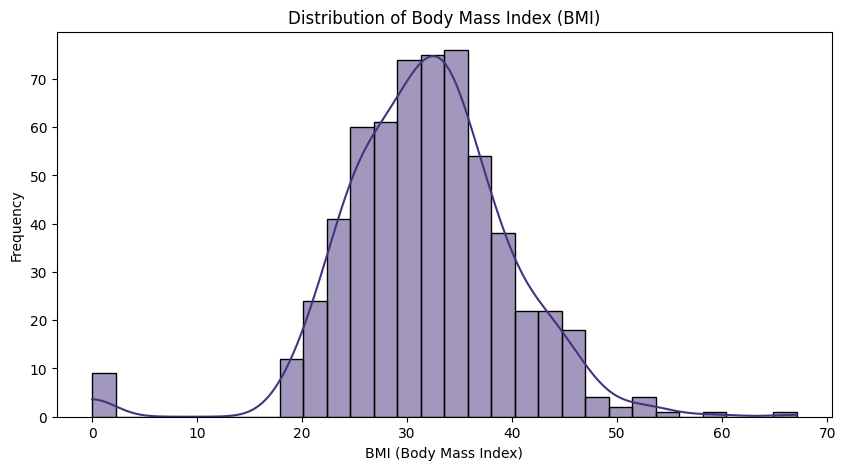

Summary Statistics for Body Mass Index (BMI):
count    599.000000
mean      31.920033
std        8.008227
min        0.000000
25%       27.100000
50%       32.000000
75%       36.550000
max       67.100000
Name: M11, dtype: float64


In [15]:
m11_values = train_df['M11']
plt.figure(figsize=(10, 5))
sns.histplot(m11_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Body Mass Index (BMI)')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Body Mass Index (BMI):')
print(m11_values.describe())

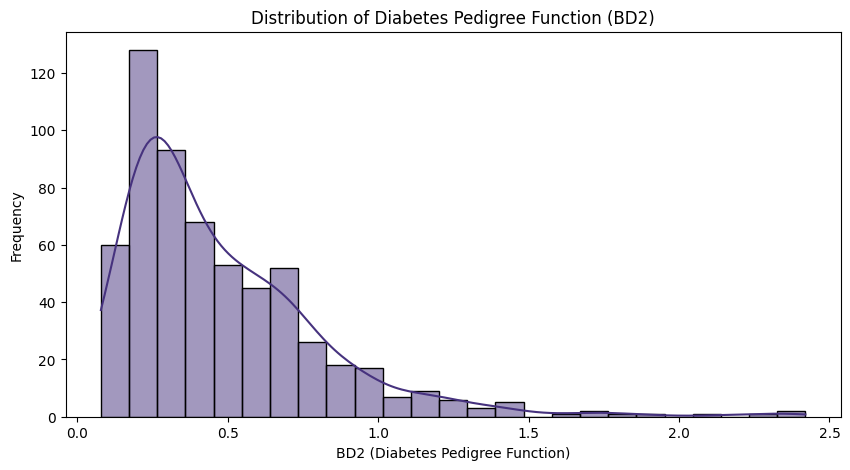

Summary Statistics for Diabetes Pedigree Function (BD2):
count    599.000000
mean       0.481187
std        0.337552
min        0.078000
25%        0.248000
50%        0.383000
75%        0.647000
max        2.420000
Name: BD2, dtype: float64


In [16]:
bd2_values = train_df['BD2']
plt.figure(figsize=(10, 5))
sns.histplot(bd2_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Diabetes Pedigree Function (BD2)')
plt.xlabel('BD2 (Diabetes Pedigree Function)')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Diabetes Pedigree Function (BD2):')
print(bd2_values.describe())

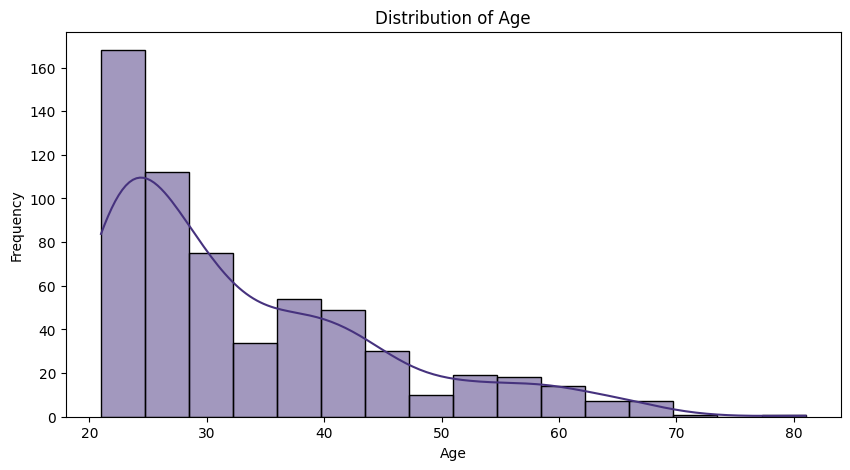

Summary Statistics for Age:
count    599.000000
mean      33.290484
std       11.828446
min       21.000000
25%       24.000000
50%       29.000000
75%       40.000000
max       81.000000
Name: Age, dtype: float64


In [17]:
age_values = train_df['Age']
plt.figure(figsize=(10, 5))
sns.histplot(age_values, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
print('Summary Statistics for Age:')
print(age_values.describe())

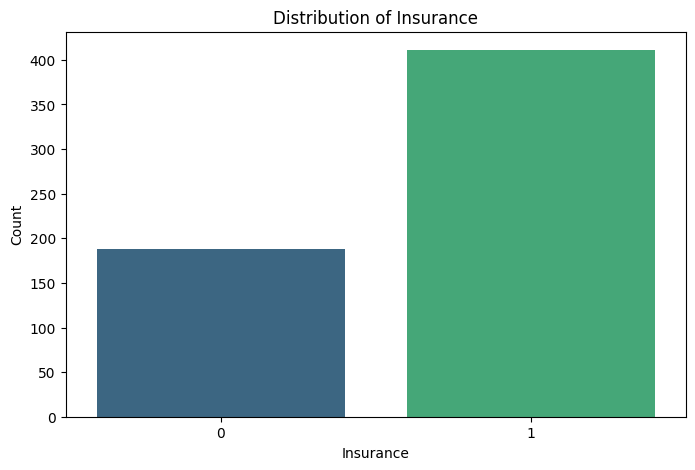

Summary Statistics for Insurance Coverage:
count    599.000000
mean       0.686144
std        0.464447
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Insurance, dtype: float64
Insurance
1    411
0    188
Name: count, dtype: int64


In [18]:
insurance_values = train_df['Insurance']
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Insurance', palette='viridis')
plt.title('Distribution of Insurance')
plt.xlabel('Insurance')
plt.ylabel('Count')
plt.show()
print('Summary Statistics for Insurance Coverage:')
print(insurance_values.describe())
insurance_counts = insurance_values.value_counts()
print(insurance_counts)

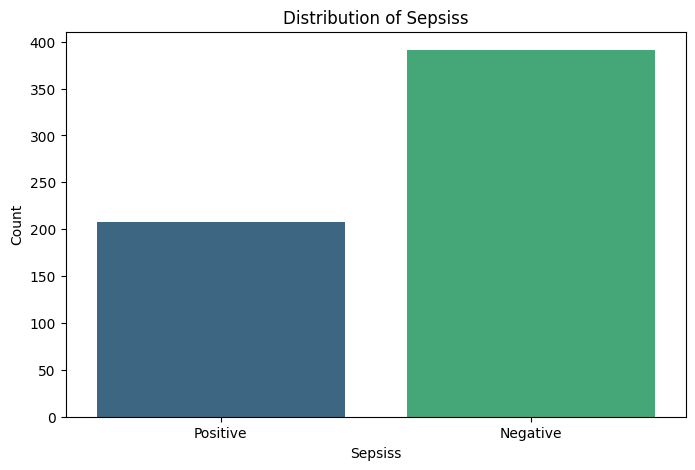

,count
Sepssis,
Negative,391
Positive,208


In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Sepssis', palette='viridis')
plt.title('Distribution of Sepsiss')
plt.xlabel('Sepsiss')
plt.ylabel('Count')
plt.show()
train_df['Sepssis'].value_counts()

# **Findings after individual column inspection-**
1. The average number of pregnancies is approximately 3.83, suggesting that, on average, patients have had several pregnancies.
2. The range of values varies from 0 to 17 pregnancies. The majority of patients fall within the range of 1 to 6 pregnancies.
3. The mean plasma glucose concentration is around 120.15 mg/dL.
4. The values range from a minimum of 0 mg/dL to 198 mg/dL. The standard deviation of 32.68 indicates some variability in glucose levels among patients.
5. The mean diastolic blood pressure is approximately 68.73 mm Hg.
The values range from a minimum of 0 mm Hg to a maximum of 122 mm Hg.
Most patients have diastolic blood pressure levels within the range of 64 to 80 mm Hg.
6. The mean triceps skinfold thickness is around 20.56 mm. There is a spread in skinfold thickness among patients.
7. The mean 2-hour serum insulin level is approximately 79.46 μU/ml.
The values have a wide range, with a minimum of 0 μU/ml and a maximum of 846 μU/ml. The standard deviation of 116.58 suggests significant variability in insulin levels.
8. The mean BMI is approximately 31.92, indicating that, on average, patients have a BMI in the overweight range.
9. The mean diabetes pedigree function value is 0.481, which reflects the diabetes history in family members. Values range from a minimum of 0.078 to a maximum of 2.42.
10. The average age of patients is approximately 33.29 years. Ages range from a minimum of 21 years to a maximum of 81 years. Most patients fall within the range of 24 to 40 years.
11. There are 411 patients with insurance, which is 68.61% of the total, and 188 patients without insurance, which is 31.39% of the total.
12. There are 208 patients with sepsis (Positive) and 391 patients without sepsis (Negative). The distribution shows an imbalance, with more patients without sepsis.

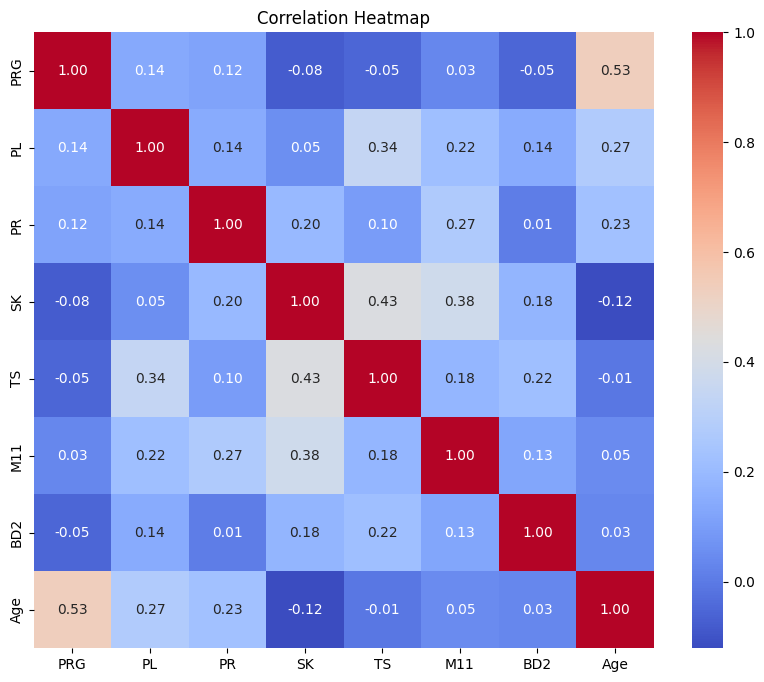

In [20]:
corr_matrix = train_df[['PRG', 'PL', 'PR', 'SK', 'TS', 'M11', 'BD2', 'Age']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()




*   Age and Number of Pregnancies (PRG): There is a moderately positive correlation (0.53) between the number of pregnancies (PRG) and age. This suggests that, on average, older individuals tend to have more pregnancies.
*   Plasma Glucose (PL) and 2-Hour Serum Insulin (TS): Plasma glucose (PL) and 2-hour serum insulin (TS) exhibit a moderate positive correlation (0.34). This correlation indicates that higher plasma glucose levels are associated with higher 2-hour serum insulin levels.
*   Skinfold Thickness (SK) and 2-Hour Serum Insulin (TS): Skinfold thickness (SK) and 2-hour serum insulin (TS) have a relatively strong positive correlation (0.43). This implies that individuals with higher skinfold thickness may tend to have higher 2-hour serum insulin levels.





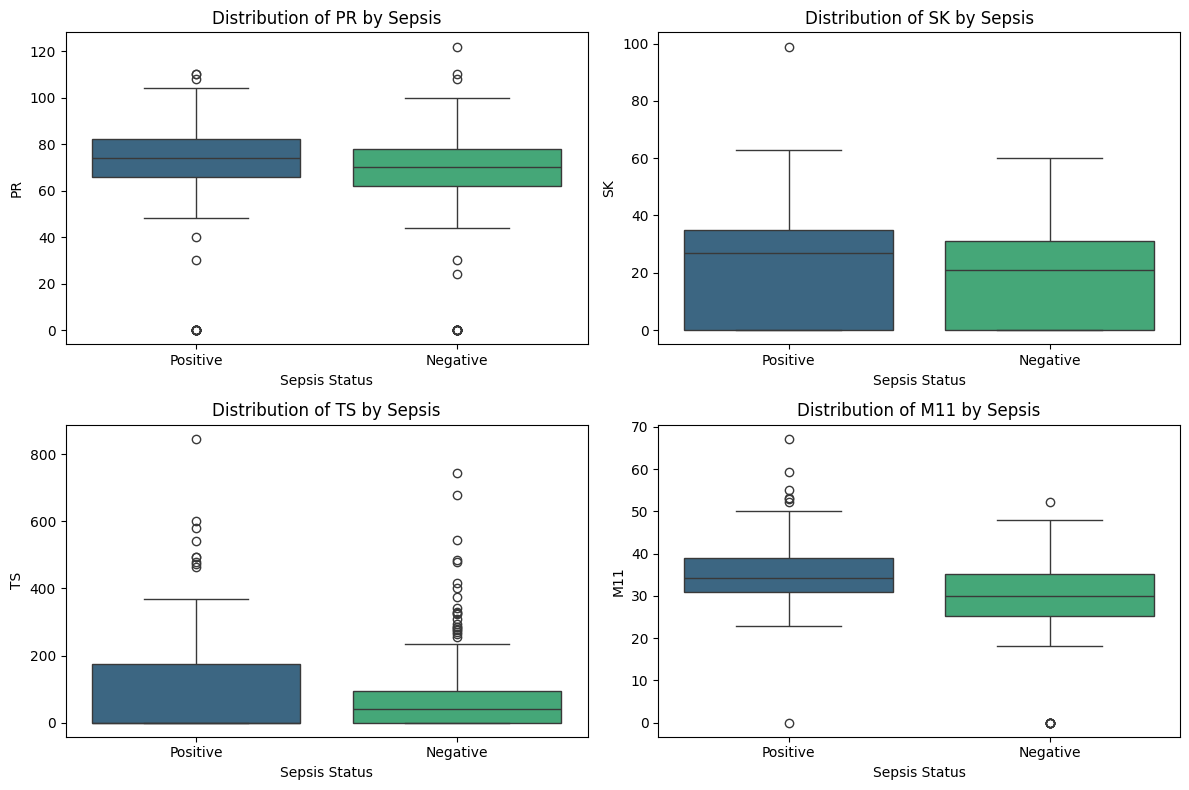

In [21]:
plt.figure(figsize=(12, 8))
numerical_variables = ['PR', 'SK', 'TS', 'M11']
colors = sns.color_palette('viridis', n_colors=2)
for i, variable in enumerate(numerical_variables):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='Sepssis', y=variable, data=train_df, hue='Sepssis', palette=colors)
    plt.title(f'Distribution of {variable} by Sepsis')
    plt.xlabel('Sepsis Status')
    plt.ylabel(variable)
plt.tight_layout()
plt.show()

# **Feature engineering**

In [22]:
age_intervals = [20, 40, 60, 80, 90]
age_labels = ['20-39', '40-59', '60-79', '80-90']
train_df['Age Group'] = pd.cut(train_df['Age'], bins=age_intervals, labels=age_labels)
test_df['Age Group'] = pd.cut(test_df['Age'], bins=age_intervals, labels=age_labels)
columns_to_impute = ['PL', 'PR', 'SK', 'M11']
for column in columns_to_impute:
    zero_rows_train = train_df[train_df[column] == 0]
    zero_rows_test = test_df[test_df[column] == 0]
    for age_group in age_labels:
        age_group_mean_train = train_df[train_df['Age Group'] == age_group][column].mean()
        age_group_mean_test = test_df[test_df['Age Group'] == age_group][column].mean()
        train_df.loc[(train_df['Age Group'] == age_group) & (train_df[column] == 0), column] = age_group_mean_train
        test_df.loc[(test_df['Age Group'] == age_group) & (test_df[column] == 0), column] = age_group_mean_test

In [23]:
train_df.describe()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance
count,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000,599.000000
mean,3.824708,121.148985,71.901390,26.360109,79.460768,32.398889,0.481187,33.290484,0.686144
std,3.362839,30.767905,11.961464,10.091526,116.576176,6.969327,0.337552,11.828446,0.464447
min,0.000000,44.000000,24.000000,7.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,19.000000,0.000000,27.400000,0.248000,24.000000,0.000000
50%,3.000000,116.669623,70.000000,23.000000,36.000000,32.000000,0.383000,29.000000,1.000000
75%,6.000000,140.000000,80.000000,32.000000,123.500000,36.550000,0.647000,40.000000,1.000000
max,17.000000,198.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
test_df.describe()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Insurance
count,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,3.917160,123.520710,73.274787,26.588964,81.000000,32.600409,0.438876,33.065089,0.727811
std,3.402415,29.259123,12.783183,9.091937,110.720852,6.562578,0.306935,11.548110,0.446410
min,0.000000,56.000000,38.000000,10.000000,0.000000,19.500000,0.100000,21.000000,0.000000
25%,1.000000,102.000000,64.000000,20.000000,0.000000,27.700000,0.223000,24.000000,0.000000
50%,3.000000,120.000000,74.000000,23.000000,0.000000,32.400000,0.343000,28.000000,1.000000
75%,6.000000,141.000000,80.000000,32.000000,135.000000,36.600000,0.587000,42.000000,1.000000
max,13.000000,199.000000,114.000000,49.000000,540.000000,57.300000,1.698000,70.000000,1.000000


In [25]:
train_df.drop(['ID', 'Age Group', 'Insurance'], axis=1, inplace=True)
test_df.drop(['ID', 'Age Group', 'Insurance'], axis=1, inplace=True)

In [26]:
train_df.head()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Sepssis
0,6,148.0,72.0,35.000000,0,33.6,0.627,50,Positive
1,1,85.0,66.0,29.000000,0,26.6,0.351,31,Negative
2,8,183.0,64.0,21.472284,0,23.3,0.672,32,Positive
3,1,89.0,66.0,23.000000,94,28.1,0.167,21,Negative
4,0,137.0,40.0,35.000000,168,43.1,2.288,33,Positive


In [27]:
test_df.head()

,PRG,PL,PR,SK,TS,M11,BD2,Age
0,1,109.0,38.000000,18.000000,120,23.1,0.407,26
1,1,108.0,88.000000,19.000000,0,27.1,0.400,24
2,6,96.0,67.081301,21.382114,0,23.7,0.190,28
3,1,124.0,74.000000,36.000000,0,27.8,0.100,30
4,7,150.0,78.000000,29.000000,126,35.2,0.692,54


In [28]:
label_encoder = LabelEncoder()
train_df['Sepssis'] = label_encoder.fit_transform(train_df['Sepssis'])
train_df.head()

,PRG,PL,PR,SK,TS,M11,BD2,Age,Sepssis
0,6,148.0,72.0,35.000000,0,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,0,26.6,0.351,31,0
2,8,183.0,64.0,21.472284,0,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168,43.1,2.288,33,1


# **Train - Test Split**

In [29]:
from imblearn.over_sampling import RandomOverSampler

In [30]:
X = train_df.drop('Sepssis', axis=1)
y = train_df['Sepssis']
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape of the Training Set (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape of the Evaluation Set (X_eval, y_eval):", X_eval.shape, y_eval.shape)

Shape of the Training Set (X_train, y_train): (479, 8) (479,)
Shape of the Evaluation Set (X_eval, y_eval): (120, 8) (120,)


In [31]:
oversampler = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = oversampler.fit_resample(X_train, y_train)
balanced_class_counts = y_train_balanced.value_counts()
print("\nClass distribution in the balanced training set:")
print(balanced_class_counts)


Class distribution in the balanced training set:
Sepssis
0    313
1    313
Name: count, dtype: int64


In [32]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_eval_scaled = scaler.transform(X_eval)

In [33]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_eval_scaled_df = pd.DataFrame(X_eval_scaled, columns=X.columns)
y_train_balanced_df = pd.DataFrame(y_train_balanced, columns=['Sepssis'])
print("Shape of X_train_scaled_df:", X_train_scaled_df.shape)
print("Shape of X_eval_scaled_df:", X_eval_scaled_df.shape)
print("Shape of y_train_balanced_df:", y_train_balanced_df.shape)
print("Shape of y_eval:", y_eval.shape)

Shape of X_train_scaled_df: (626, 8)
Shape of X_eval_scaled_df: (120, 8)
Shape of y_train_balanced_df: (626, 1)
Shape of y_eval: (120,)


In [34]:
X_train_scaled_df.head()

,PRG,PL,PR,SK,TS,M11,BD2,Age
0,0.411765,0.319149,0.478261,0.358696,0.141129,0.461165,0.051370,0.400000
1,0.411765,0.879433,0.586957,0.152174,0.258065,0.429612,0.214897,0.500000
2,0.117647,0.170213,0.456522,0.086957,0.102151,0.288835,0.198202,0.066667
3,0.176471,0.872340,0.369565,0.195652,0.094086,0.383495,0.080051,0.083333
4,0.000000,0.191489,0.369565,0.163043,0.088710,0.427184,0.197346,0.000000


In [35]:
X_eval_scaled_df.head()

,PRG,PL,PR,SK,TS,M11,BD2,Age
0,0.176471,0.219858,0.304348,0.043478,0.072581,0.160194,0.078339,0.016667
1,0.529412,0.702128,0.608696,0.228261,0.208333,0.390777,0.473031,0.350000
2,0.000000,0.312057,0.347826,0.157307,0.000000,0.089806,0.107877,0.066667
3,0.117647,0.631206,0.500000,0.304348,0.260753,0.485437,0.104880,0.133333
4,0.000000,0.404255,0.543478,0.293478,0.383065,0.631068,0.035531,0.100000


In [36]:
Results = {'Model':[], 'Acurracy':[], 'Precision':[], 'Recall':[], 'F1':[]}
Result=pd.DataFrame(Results)
Result.head()

,Model,Acurracy,Precision,Recall,F1


In [37]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier()
gb = GradientBoostingClassifier()
nb = GaussianNB()
svm = SVC()

Model: Logistic Regression
Classification report:
Accuracy: 0.7083333333333334
Precision: 0.5660377358490566
Recall: 0.7142857142857143
F1 Score: 0.631578947368421


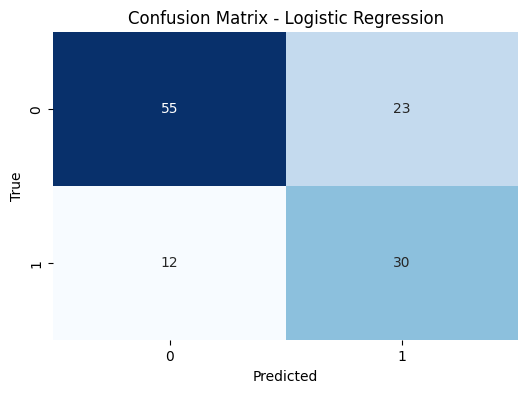



Model: Random Forest
Classification report:
Accuracy: 0.7416666666666667
Precision: 0.627906976744186
Recall: 0.6428571428571429
F1 Score: 0.6352941176470588


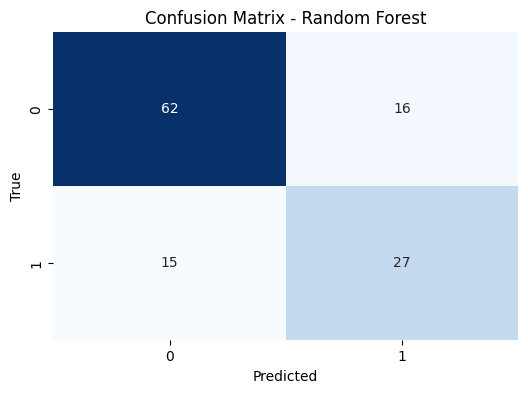



Model: K-Nearest Neighbors
Classification report:
Accuracy: 0.75
Precision: 0.6071428571428571
Recall: 0.8095238095238095
F1 Score: 0.6938775510204082


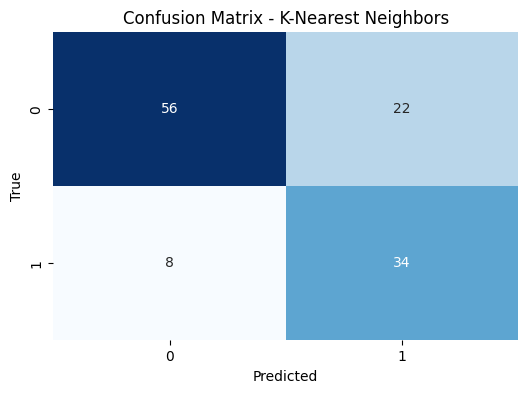



Model: Decision Tree
Classification report:
Accuracy: 0.7
Precision: 0.5681818181818182
Recall: 0.5952380952380952
F1 Score: 0.5813953488372093


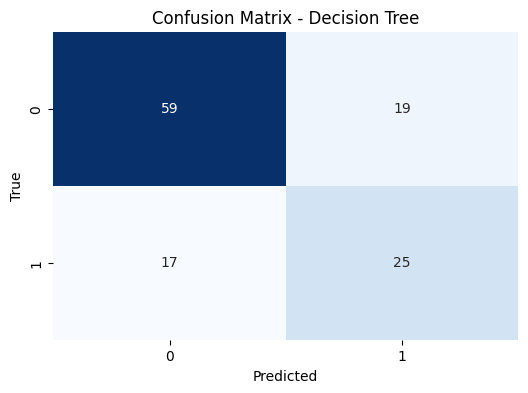



Model: Gradient Boosting
Classification report:
Accuracy: 0.7666666666666667
Precision: 0.64
Recall: 0.7619047619047619
F1 Score: 0.6956521739130435


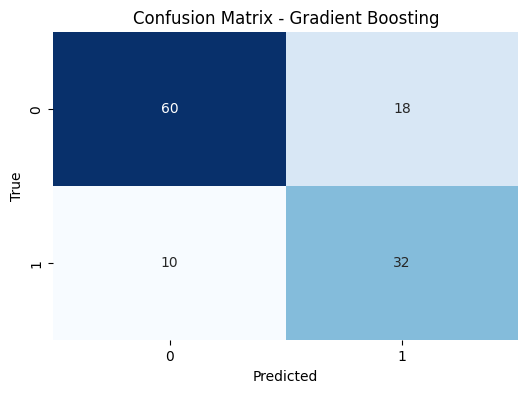



Model: Naive Bayes
Classification report:
Accuracy: 0.675
Precision: 0.5283018867924528
Recall: 0.6666666666666666
F1 Score: 0.5894736842105263


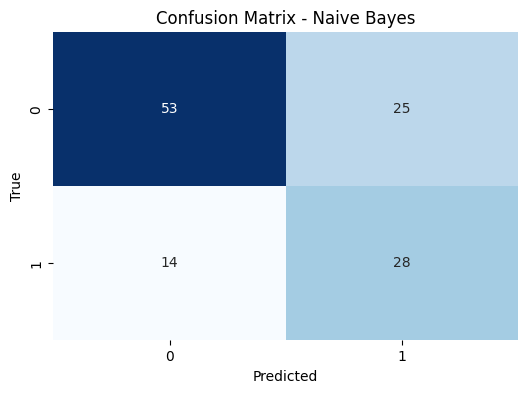



Model: Support Vector Machine
Classification report:
Accuracy: 0.7083333333333334
Precision: 0.574468085106383
Recall: 0.6428571428571429
F1 Score: 0.6067415730337079


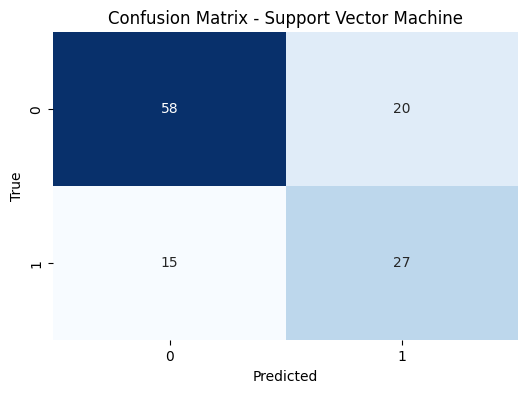

In [38]:
models={'Logistic Regression':lr, 'Random Forest':rf, 'K-Nearest Neighbors':knn, 'Decision Tree':dt, 'Gradient Boosting':gb, 'Naive Bayes':nb, 'Support Vector Machine':svm}
for name,model in models.items():
    model.fit(X_train_scaled_df, y_train_balanced)
    y_pred = model.predict(X_eval_scaled_df)
    accuracy = accuracy_score(y_eval, y_pred)
    precision = precision_score(y_eval, y_pred)
    recall = recall_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred)
    print(f"Model: {name}")
    print("Classification report:")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    print("\n")
    new_row = {
        'Model': name,
        'Accuracy': round(accuracy, 2),
        'Precision': round(precision, 2),
        'Recall': round(recall, 2),
        'F1': round(f1, 2)
    }
    Result = pd.concat([Result, pd.DataFrame([new_row])], ignore_index=True)

In [40]:
result = Result.sort_values(by='F1', ascending=False)
print(result)

                    Model  Acurracy  Precision  Recall    F1  Accuracy
4       Gradient Boosting       NaN       0.64    0.76  0.70      0.77
2     K-Nearest Neighbors       NaN       0.61    0.81  0.69      0.75
1           Random Forest       NaN       0.63    0.64  0.64      0.74
0     Logistic Regression       NaN       0.57    0.71  0.63      0.71
6  Support Vector Machine       NaN       0.57    0.64  0.61      0.71
5             Naive Bayes       NaN       0.53    0.67  0.59      0.68
3           Decision Tree       NaN       0.57    0.60  0.58      0.70


In [41]:
gb.fit(X_train_scaled_df, y_train_balanced_df)

GradientBoostingClassifier()

In [42]:
pip install shap

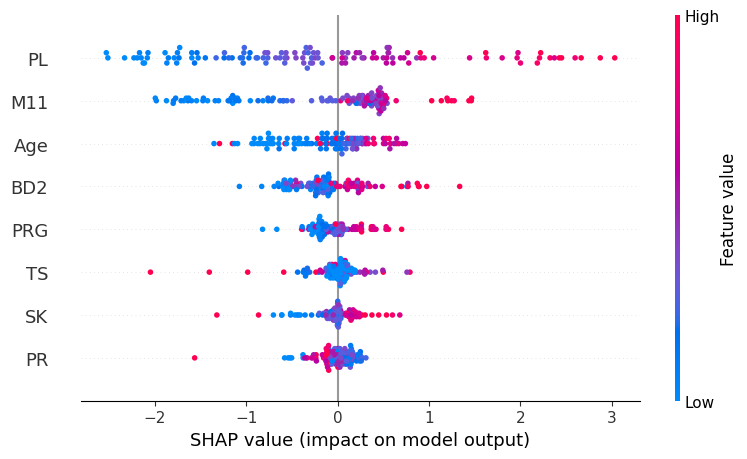

In [46]:
import shap
explainer = shap.Explainer(gb)
shap_values = explainer(X_eval_scaled_df)
shap.initjs()
shap.summary_plot(shap_values, X_eval_scaled_df)

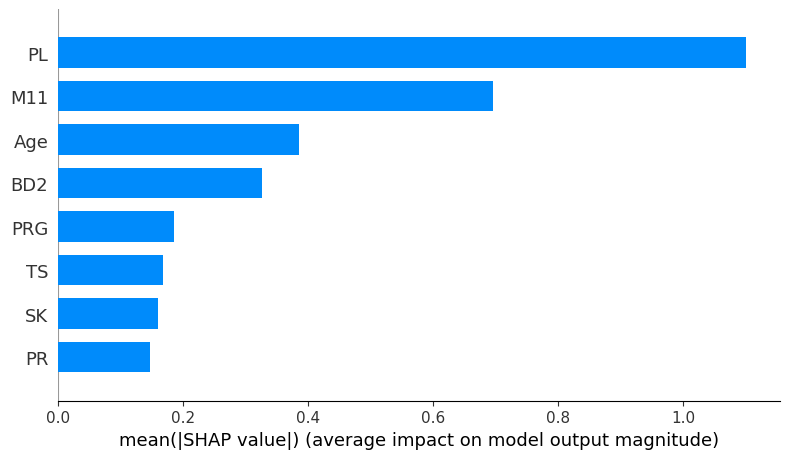

In [49]:
shap.summary_plot(shap_values, X_eval_scaled_df, plot_type="bar")

Features like Plasma Glucose Concentration (PL) and Body Mass Index (M11) are particularly significant, while others, like Diastolic Blood Pressure (PR), Triceps Skinfold Thickness (SK), 2-Hour Serum Insulin (TS), Number of Pregnancies (PRG), Age, Diabetes Pedigree Function (BD2) have a comparatively lower impact on the model's predictive power.

In [51]:
param_grid = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled_df, y_train_balanced_df)
print(f"Best Score: {grid_search.best_score_}")
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Score: 0.8594903099925146
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}


Classification report:
Accuracy: 0.7583333333333333
Precision: 0.6444444444444445
Recall: 0.6904761904761905
F1 Score: 0.6666666666666666


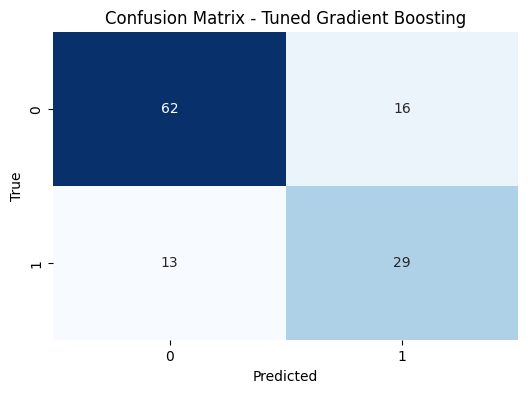

In [52]:
tuned_gb=GradientBoostingClassifier(learning_rate=0.1, max_depth=7, min_samples_split=2, n_estimators=200, subsample=1.0)
tuned_gb.fit(X_train_scaled_df, y_train_balanced_df)
y_pred = tuned_gb.predict(X_eval_scaled_df)
accuracy = accuracy_score(y_eval, y_pred)
precision = precision_score(y_eval, y_pred)
recall = recall_score(y_eval, y_pred)
f1 = f1_score(y_eval, y_pred)
print("Classification report:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
cm= confusion_matrix(y_eval, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [53]:
saved_components = {
    'model': tuned_gb,
    'encoder': label_encoder,
    'scaler': scaler
}
with open('model_and_key_components.pkl', 'wb') as file:
    pickle.dump(saved_components, file)